# 🚗 Car Price Prediction

### 🎯 Objective

Build a **Machine Learning Regression model** to predict the selling price of a used car based on features such as car name, year, present price, kilometers driven, fuel type, transmission, and previous owners.

### 🔄 Workflow

**Data Understanding → Data Cleaning → EDA → Feature Engineering → Preprocessing → Model Training → Evaluation → Prediction**

### 📌 ML Type

* **Learning:** Supervised Learning
* **Problem:** Regression
* **Target:** `Selling_Price`
* **Metrics:** MAE, RMSE, R²


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('../Data/used_cars.csv')

In [3]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [4]:
df.shape

(4009, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [6]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [7]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [8]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [9]:
df['fuel_type'].value_counts()

fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [12]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [13]:
df.describe(include='object')

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


In [14]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [15]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [16]:
df['price'].head()

0    10300.0
1    38005.0
2    54598.0
3    15500.0
4    34999.0
Name: price, dtype: float64

In [17]:
df["price"].dtype

dtype('float64')

In [18]:
df['milage'] = (
    df['milage']
    .str.replace(',','',regex=False) 
    .str.replace(' mi.','',regex=False)
    .astype(float)
)

In [19]:
df['milage'].head()

0    51000.0
1    34742.0
2    22372.0
3    88900.0
4     9835.0
Name: milage, dtype: float64

In [20]:
df["milage"].dtype

dtype('float64')

<Axes: xlabel='price', ylabel='Count'>

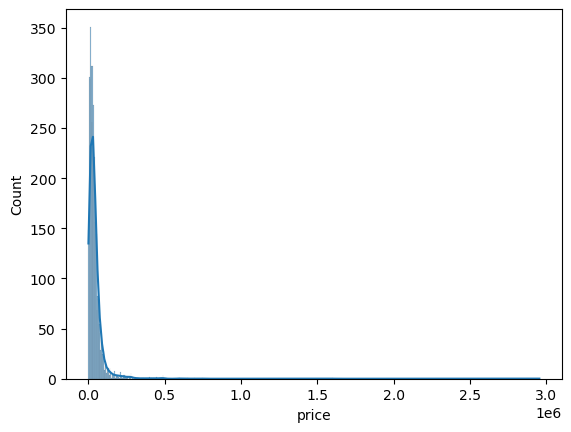

In [21]:
sns.histplot(df['price'],kde=True)

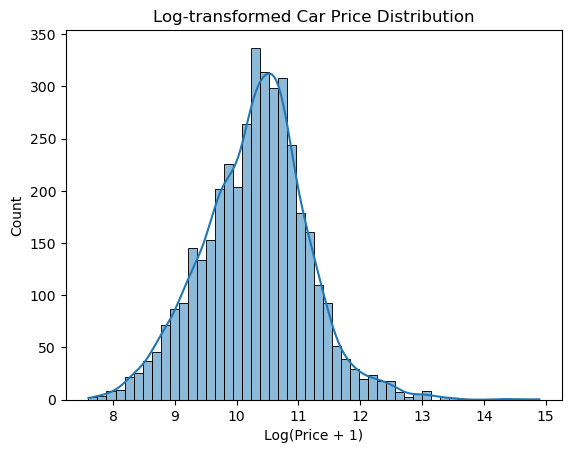

In [22]:
sns.histplot(np.log1p(df['price']),bins=50,kde=True)
plt.xlabel("Log(Price + 1)")
plt.title("Log-transformed Car Price Distribution")

plt.show()

In [23]:
compress_price = np.log1p(df['price'])

<Axes: xlabel='model_year', ylabel='price'>

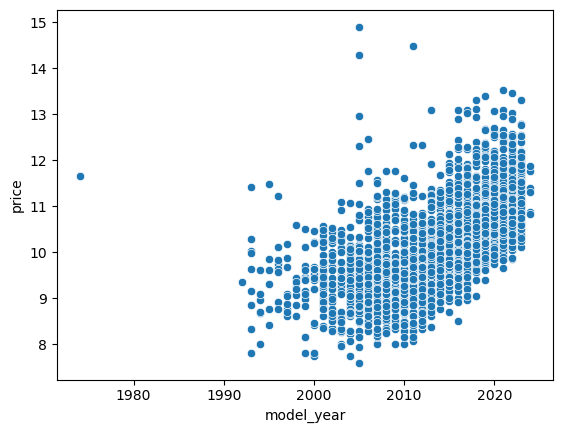

In [24]:
sns.scatterplot(
    data=df, 
    x='model_year', 
    y=compress_price
)

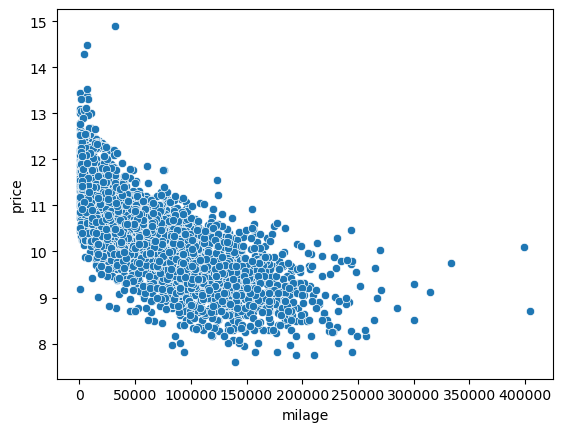

In [25]:
sns.scatterplot(
    data=df,
    x="milage",
    y=compress_price
)

plt.show()

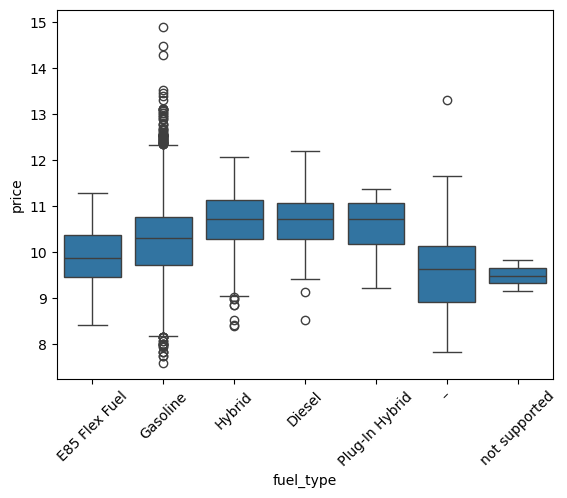

In [26]:
sns.boxplot(
    data=df,
    x="fuel_type",
    y=compress_price
)

plt.xticks(rotation=45)
plt.show()

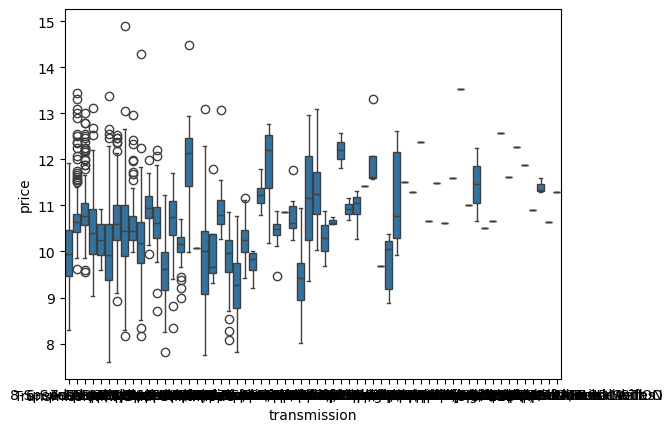

In [27]:
sns.boxplot(
    data=df,
    x="transmission",
    y=compress_price
)

plt.show()

In [28]:
CURRENT_YEAR = 2026 

df['car_age']  = CURRENT_YEAR  - df['model_year']

In [29]:
df[['model_year','car_age']].head()

,model_year,car_age
0,2013,13
1,2021,5
2,2022,4
3,2015,11
4,2021,5


In [30]:
df['price'].describe()

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

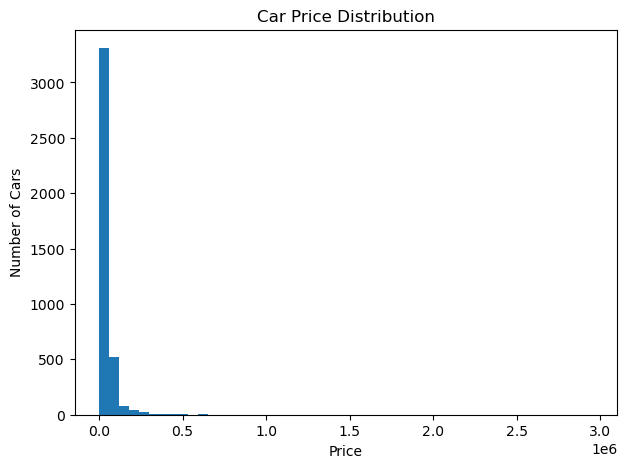

In [31]:
plt.figure(figsize=(7, 5))

plt.hist(df["price"], bins=50)

plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.title("Car Price Distribution")

plt.show()

In [32]:
df['price'].min(),df['price'].max()

(2000.0, 2954083.0)

In [33]:
df["milage"].min(), df["milage"].max()

(100.0, 405000.0)

In [34]:
df["model_year"].min(), df["model_year"].max()

(1974, 2024)

In [35]:
print('Updated')

Updated


In [37]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,13
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,5
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,4
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,11
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,5


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     3839 non-null   object 
 5   engine        4009 non-null   object 
 6   transmission  4009 non-null   object 
 7   ext_col       4009 non-null   object 
 8   int_col       4009 non-null   object 
 9   accident      3896 non-null   object 
 10  clean_title   3413 non-null   object 
 11  price         4009 non-null   float64
 12  car_age       4009 non-null   int64  
dtypes: float64(2), int64(2), object(9)
memory usage: 407.3+ KB


In [42]:
categorical_cols = [
    "brand",
    "model",
    "fuel_type",
    "engine",
    "transmission",
    "ext_col",
    "int_col",
    "accident",
    "clean_title"
]
numerical_cols = [
    "model_year",
    "car_age",
    "milage"
]
target = 'price'

In [72]:
X = df.drop('price',axis=1)
Y = np.log1p(df['price'])

In [73]:
x_train,x_test,y_train,y_test = train_test_split(
    X,
    Y, 
    test_size=0.2, 
    random_state=42
)

In [74]:
numerical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')), 
    ('scaler',StandardScaler())
])

In [75]:
numerical_pipeline

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [76]:
categorical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')), 
    ('onehot',OneHotEncoder(
        handle_unknown='ignore'
    ))
])

In [77]:
categorical_pipeline

,steps,"[('imputer', ...), ('onehot', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [78]:
preprocessor = ColumnTransformer([
    ('num',numerical_pipeline,numerical_cols), 
    ('cat',categorical_pipeline,categorical_cols)
])

In [79]:
liner_model = Pipeline([
    ('preprocessor',preprocessor), 
    ('model',LinearRegression())
])

In [80]:
liner_model.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
y_pred = liner_model.predict(x_test)

In [82]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.24977457873763245
RMSE: 0.4475881872864218
R²: 0.7427252836823195


In [83]:
rf_model = Pipeline([
    ('preprocessor',preprocessor), 
    ('model',RandomForestRegressor(
        n_estimators=300, 
        random_state=42, 
        n_jobs=-1
    ))
])

In [84]:
rf_model.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [85]:
rf_pred = rf_model.predict(x_test)

In [86]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

MAE: 0.3104822979318538
RMSE: 0.45403962990760366
R²: 0.7352552249409832


In [87]:
results = pd.DataFrame({
    'Model':[
        'Linear Regression', 
        'Random Forest'
    ], 
    'MAE':[
        mae, 
        rf_mae
    ], 
    'RMSE':[
        rmse, 
        rf_rmse
    ], 
    'R2':[
        r2, 
        rf_r2
    ]
})

In [88]:
results

,Model,MAE,RMSE,R2
0,Linear Regression,0.249775,0.447588,0.742725
1,Random Forest,0.310482,0.454040,0.735255


In [89]:
comparion = pd.DataFrame({
    'Actual': y_test.values, 
    'Predicted':rf_pred
})
comparion['Absolute_error'] = abs(
    comparion['Actual']  - comparion['Predicted']
)
comparion.sort_values('Absolute_error',ascending=False).head(20)

,Actual,Predicted,Absolute_error
70,14.898699,10.024981,4.873718
165,14.483851,11.721111,2.762740
493,14.284890,11.803211,2.481679
548,12.971538,10.915099,2.056439
95,13.102153,11.319712,1.782441
729,9.190240,10.881173,1.690933
218,8.779711,10.428356,1.648645
96,12.287657,10.707103,1.580554
680,8.810012,10.188358,1.378346
164,8.517393,9.859546,1.342153


In [90]:
df['price'].describe()

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

In [91]:
df["price"].sort_values(ascending=False).head(20)

693     2954083.0
229     1950995.0
3046    1599000.0
1356     749950.0
624      695000.0
979      649999.0
1615     599995.0
1508     599000.0
3655     491836.0
1061     489995.0
1148     489000.0
304      488880.0
2133     479995.0
1597     469900.0
487      449995.0
2111     449991.0
203      429998.0
3611     425000.0
180      417500.0
3816     399950.0
Name: price, dtype: float64

In [92]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,13
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,5
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,4
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,11
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,5
